# Project Overview

The objective of this project is to analyze the Olist Brazilian E-Commerce dataset and identify the key factors that influence business performance, customer satisfaction, and delivery efficiency.

The analysis combines customer, order, product, payment, and review data to generate actionable business insights. The project focuses on understanding revenue drivers, customer purchasing behavior, payment preferences, product category performance, delivery effectiveness, and customer satisfaction.

Using Python and Pandas, multiple datasets were merged into a unified analytical dataset. Exploratory Data Analysis (EDA) was performed to evaluate sales trends, payment behavior, review patterns, regional performance, and delivery outcomes.

The analysis aims to answer the following business questions:

* Which product categories generate the highest revenue?
* Which states contribute the most revenue?
* How do payment methods influence revenue?
* What is the relationship between delivery performance and customer satisfaction?
* Which regions experience the highest delivery delays?
* What business actions can improve customer experience and revenue growth?

The findings provide data-driven recommendations to support operational improvements, customer retention, and business growth.


In [1]:
import pandas as pd
import os

In [6]:
data_path = "data"

orders = pd.read_csv(os.path.join(data_path, "olist_orders_dataset.csv"))
customers = pd.read_csv(os.path.join(data_path, "olist_customers_dataset.csv"))
items = pd.read_csv(os.path.join(data_path, "olist_order_items_dataset.csv"))
products = pd.read_csv(os.path.join(data_path, "olist_products_dataset.csv"))
payments = pd.read_csv(os.path.join(data_path, "olist_order_payments_dataset.csv"))
reviews = pd.read_csv(os.path.join(data_path, "olist_order_reviews_dataset.csv"))
sellers = pd.read_csv(os.path.join(data_path, "olist_sellers_dataset.csv"))
translation = pd.read_csv(os.path.join(data_path, "product_category_name_translation.csv"))


In [7]:
orders.shape, customers.shape, items.shape, products.shape, payments.shape, reviews.shape

((99441, 8), (99441, 5), (112650, 7), (32951, 9), (103886, 5), (99224, 7))

In [8]:
orders.head()
items.head()
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [9]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [10]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [11]:
items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [12]:
products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [13]:
payments.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

In [14]:
orders_customers = pd.merge(
    orders,
    customers,
    on='customer_id',
    how='left'
)

orders_customers.shape

(99441, 12)

In [15]:
df = pd.merge(
    orders_customers,
    items,
    on='order_id',
    how='left'
)

df.shape

(113425, 18)

In [16]:
df = pd.merge(
    df,
    products,
    on='product_id',
    how='left'
)

df.shape

(113425, 26)

In [17]:
df.shape

(113425, 26)

In [18]:
df = pd.merge(
    df,
    payments,
    on='order_id',
    how='left'
)

df.shape

(118434, 30)

In [19]:
df = pd.merge(
    df,
    reviews,
    on='order_id',
    how='left'
)

df.shape

(119143, 36)

In [20]:
df = pd.merge(
    df,
    translation,
    on='product_category_name',
    how='left'
)

df.shape

(119143, 37)

In [21]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,auto


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   customer_unique_id             119143 non-null  object 
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  object 
 11  customer_state                 119143 non-null  object 
 12  order_item_id                 

In [23]:
df.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                               833
freight_value                       833
product_category_name              2542
product_name_lenght                2542
product_description_lenght         2542
product_photos_qty                 2542
product_weight_g                    853
product_length_cm                   853
product_height_cm                   853


## Data cleaning

In [24]:
df_clean = df.drop(columns=[
    'review_comment_title',
    'review_comment_message'
])

In [25]:
df_clean = df_clean.dropna(subset=['price', 'product_id', 'seller_id'])

Type conversion

In [26]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date',
    'review_answer_timestamp'
]

for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

In [27]:
df_clean['product_category_name_english'] = df_clean['product_category_name_english'].fillna('Unknown')

In [28]:
df_clean = df_clean.dropna(subset=['payment_type', 'payment_value'])

In [29]:
df_clean.shape
df_clean.isnull().sum().sort_values(ascending=False).head(15)

order_delivered_customer_date    2588
product_name_lenght              1709
product_category_name            1709
product_description_lenght       1709
product_photos_qty               1709
order_delivered_carrier_date     1254
review_answer_timestamp           978
review_creation_date              978
review_score                      978
review_id                         978
product_length_cm                  20
product_weight_g                   20
product_width_cm                   20
product_height_cm                  20
order_approved_at                  15
dtype: int64

In [30]:
df_clean['product_category_name_english'] = df_clean['product_category_name_english'].fillna('Unknown')

In [31]:
product_num_cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_length_cm',
    'product_weight_g',
    'product_width_cm',
    'product_height_cm'
]

df_clean[product_num_cols] = df_clean[product_num_cols].fillna(0)

In [32]:
df_clean['review_score'] = df_clean['review_score'].fillna(0)

In [36]:
delivered_df = df_clean.dropna(subset=['order_delivered_customer_date']).copy()

In [37]:
delivered_df['delivery_days'] = (
    delivered_df['order_delivered_customer_date'] - delivered_df['order_purchase_timestamp']
).dt.days

delivered_df['delay_days'] = (
    delivered_df['order_delivered_customer_date'] - delivered_df['order_estimated_delivery_date']
).dt.days

delivered_df['is_late'] = delivered_df['delay_days'] > 0

## Business KPIs

In [38]:
total_revenue = round(df_clean['payment_value'].sum(), 2)

total_orders = df_clean['order_id'].nunique()

avg_review = round(
    df_clean[df_clean['review_score'] > 0]['review_score'].mean(),
    2
)

late_rate = round(
    delivered_df['is_late'].mean() * 100,
    2
)

print(total_revenue)
print(total_orders)
print(avg_review)
print(late_rate)

20416842.54
98665
4.03
6.53


In [39]:
category_sales = (
    df_clean.groupby('product_category_name_english')['payment_value']
    .sum()
    .sort_values(ascending=False)
)

category_sales.head(10)

product_category_name_english
bed_bath_table           1743998.80
health_beauty            1662963.59
computers_accessories    1599481.06
furniture_decor          1443963.61
watches_gifts            1430553.48
sports_leisure           1400223.07
housewares               1097900.09
auto                      855095.68
garden_tools              840721.59
cool_stuff                781933.97
Name: payment_value, dtype: float64

In [40]:
df_clean.groupby('review_score')['order_id'].count()

review_score
0.0      978
1.0    14854
2.0     4085
3.0     9840
4.0    22286
5.0    66264
Name: order_id, dtype: int64

In [41]:
late_by_state = (
    delivered_df.groupby('customer_state')['is_late']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

late_by_state.head(10)

customer_state
AL    21.35
MA    17.86
SE    15.80
PI    13.90
CE    13.43
BA    11.80
RJ    11.59
PA    11.12
PB    11.06
RR    10.87
Name: is_late, dtype: float64

In [42]:
revenue_by_state = (
    df_clean.groupby('customer_state')['payment_value']
    .sum()
    .round(2)
    .sort_values(ascending=False)
)

revenue_by_state.head(10)

customer_state
SP    7649963.24
RJ    2781238.85
MG    2335417.96
RS    1155433.49
PR    1069785.29
BA     800064.62
SC     788484.24
GO     518178.14
DF     436206.50
ES     407470.72
Name: payment_value, dtype: float64

In [43]:
# Average review score by late vs on-time delivery
review_by_late = delivered_df.groupby('is_late')['review_score'].mean().round(2)
review_by_late

is_late
False    4.18
True     2.20
Name: review_score, dtype: float64

In [44]:
# Revenue by payment type
payment_revenue = df_clean.groupby('payment_type')['payment_value'].sum().round(2).sort_values(ascending=False)
payment_revenue

payment_type
credit_card    15669475.07
boleto          4083687.96
voucher          409188.68
debit_card       254490.83
Name: payment_value, dtype: float64

In [45]:
# Order count by payment type
payment_orders = df_clean.groupby('payment_type')['order_id'].nunique().sort_values(ascending=False)
payment_orders

payment_type
credit_card    75991
boleto         19614
voucher         3766
debit_card      1521
Name: order_id, dtype: int64

In [46]:
# Monthly revenue trend
df_clean['order_month'] = df_clean['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = df_clean.groupby('order_month')['payment_value'].sum().round(2)
monthly_revenue.tail(12)

order_month
2017-10    1035728.78
2017-11    1595006.04
2017-12    1046223.15
2018-01    1418478.51
2018-02    1322033.76
2018-03    1482224.09
2018-04    1499340.70
2018-05    1507872.59
2018-06    1298592.17
2018-07    1354550.94
2018-08    1229748.42
2018-09        166.46
Freq: M, Name: payment_value, dtype: float64

In [47]:
# Monthly revenue trend excluding incomplete Sep 2018
monthly_revenue_clean = monthly_revenue[monthly_revenue.index != '2018-09']
monthly_revenue_clean.tail(12)

order_month
2017-09    1022896.05
2017-10    1035728.78
2017-11    1595006.04
2017-12    1046223.15
2018-01    1418478.51
2018-02    1322033.76
2018-03    1482224.09
2018-04    1499340.70
2018-05    1507872.59
2018-06    1298592.17
2018-07    1354550.94
2018-08    1229748.42
Freq: M, Name: payment_value, dtype: float64

## Business problem:
How do delivery performance, customer satisfaction, payment behavior, and product categories affect e-commerce revenue?

### charts + final insights

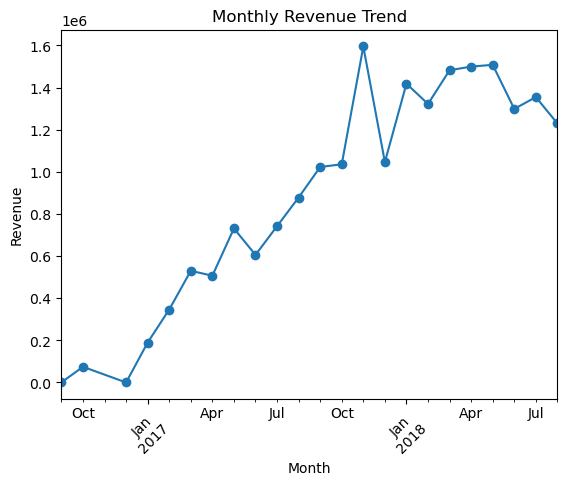

In [49]:
import matplotlib.pyplot as plt
monthly_revenue_clean.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

### 1. Review impact chart

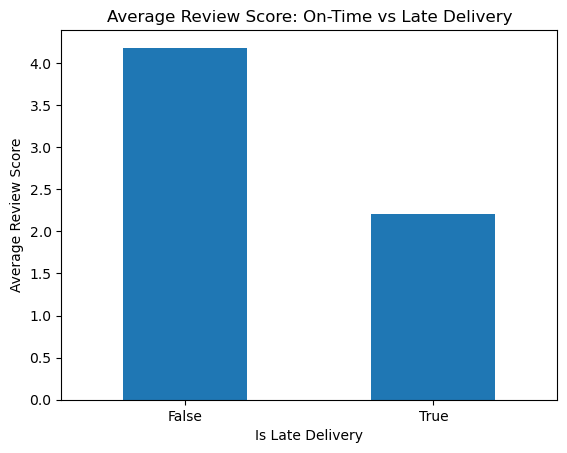

In [50]:
review_by_late.plot(kind='bar')
plt.title('Average Review Score: On-Time vs Late Delivery')
plt.xlabel('Is Late Delivery')
plt.ylabel('Average Review Score')
plt.xticks(rotation=0)
plt.show()

### 2. Payment revenue chart

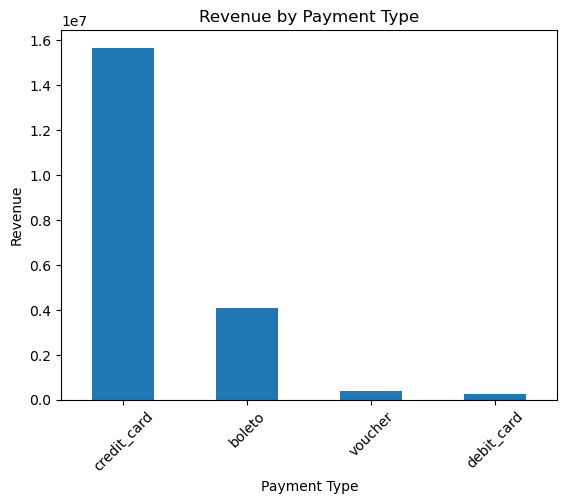

In [51]:
payment_revenue.plot(kind='bar')
plt.title('Revenue by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

### 3. Top categories chart

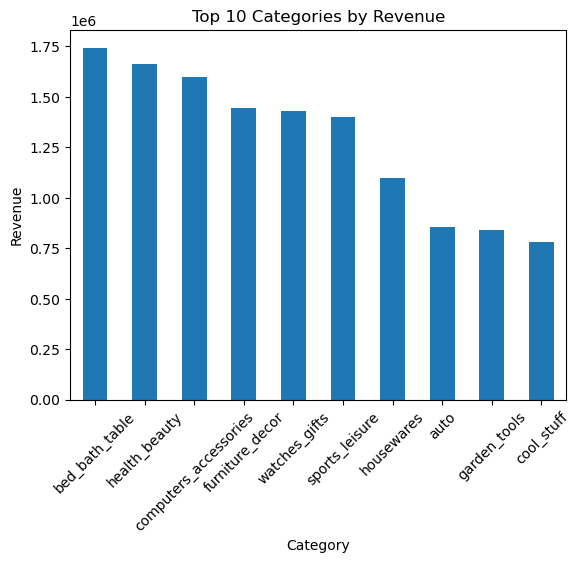

In [52]:
category_sales.head(10).plot(kind='bar')
plt.title('Top 10 Categories by Revenue')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

### 4. Revenue by state chart

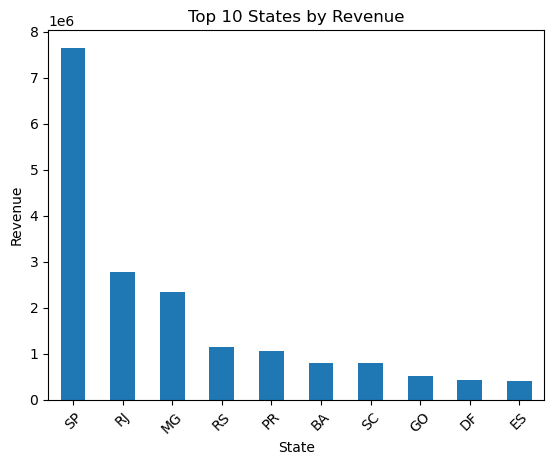

In [53]:
revenue_by_state.head(10).plot(kind='bar')
plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

## Key Insights

1. Total revenue reached 20.42M across 98,665 orders.
2. Average customer review score was 4.03, showing strong overall satisfaction.
3. Late deliveries significantly reduced customer satisfaction, with review score dropping from 4.18 to 2.20.
4. Credit card was the dominant payment method, generating 15.67M in revenue.
5. Bed, bath and table was the highest revenue category.
6. SP was the highest revenue-generating state.
7. AL had the highest late delivery rate at 21.35%.
8. September 2018 appears to be an incomplete month and should be excluded from trend analysis.

## Business Recommendations

1. Reduce late deliveries to protect customer satisfaction.
2. Focus marketing and inventory planning on top revenue categories.
3. Prioritize SP, RJ, and MG as key revenue markets.
4. Investigate high late-delivery states such as AL.
5. Monitor monthly revenue trends excluding incomplete months.

## Conclusion

This analysis shows that Olist’s e-commerce performance is driven by strong revenue from key product categories, high-performing states, and credit card payments. The business generated 20.42M in total revenue across 98,665 orders, with an average review score of 4.03, indicating generally positive customer satisfaction.

However, delivery performance has a clear impact on customer experience. On-time orders received an average review score of 4.18, while late orders dropped sharply to 2.20. This shows that delivery delays are one of the most important factors affecting customer satisfaction.

The analysis also found that credit card payments generate the majority of revenue, while categories such as bed_bath_table, health_beauty, and computers_accessories are major revenue contributors. State-level analysis showed that SP, RJ, and MG are the strongest revenue markets.

Overall, the business should focus on reducing late deliveries, improving logistics in high-delay states, strengthening top-performing product categories, and monitoring revenue trends over time. These actions can help improve customer satisfaction, increase repeat purchases, and support sustainable revenue growth.
